In [1]:
from keras.datasets import mnist

2026-09-12 11:52:12.116362: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

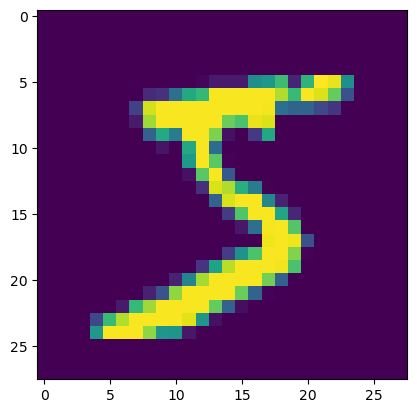

In [3]:
from matplotlib import pyplot as plt

plt.imshow(x_train[0])

In [4]:
x_train = x_train/255.0
x_test = x_test/255.0

In [5]:
from keras import layers, activations, models, optimizers, losses, metrics

In [6]:
classifier = models.Sequential(
    [
        layers.Conv2D(32, kernel_size=(3, 3), activation='relu',padding='same', input_shape=(28, 28, 1)),
        layers.BatchNormalization(),
        layers.Conv2D(32, kernel_size=(3, 3), padding='same',activation='relu', input_shape=(28, 28, 1)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, kernel_size=(3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, kernel_size=(3, 3), padding='same',activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPool2D((2, 2)),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ]
)

classifier.summary()

/home/itvaya/miniconda3/envs/ml_env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1789192334.791460  155579 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9562 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:05:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 737,642 (2.81 MB)

 Trainable params: 735,978 (2.81 MB)

 Non-trainable params: 1,664 (6.50 KB)

In [ ]:
from keras import callbacks

file_path = 'models_experiment_3/weights.{epoch:02d}-{val_sparse_categorical_accuracy:.4f}.keras'

lr_reduction = callbacks.ReduceLROnPlateau(
    monitor='val_sparse_categorical_accuracy',
    factor=1-0.2,
    patience=3,
    verbose=1,
)

model_checkpoint = callbacks.ModelCheckpoint(
    filepath=file_path,
    monitor='val_sparse_categorical_accuracy',
    verbose=1,
    save_best_only=True,
    mode='max'
)

In [8]:

classifier.compile(
    optimizer=optimizers.Adam(),
    loss=losses.SparseCategoricalCrossentropy(),
    metrics=[metrics.SparseCategoricalAccuracy()],
)

In [9]:
y_train

array([5, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=uint8)

In [10]:
x_train[0].shape

(28, 28)

In [11]:
classifier.fit(
    x=x_train,
    y=y_train,
    epochs=100,
    validation_data=(x_test, y_test),
    callbacks=[lr_reduction, model_checkpoint]
)

Epoch 1/100


2026-09-12 11:52:17.582844: I external/local_xla/xla/service/service.cc:163] XLA service 0x780548002540 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-09-12 11:52:17.582861: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2026-09-12 11:52:17.637749: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-09-12 11:52:17.942135: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91801
2026-09-12 11:52:18.152542: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-09-12 11:52:19.163616: I e

  46/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 2.2659 - sparse_categorical_accuracy: 0.3816  

I0000 00:00:1789192342.625842  155645 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1871/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3831 - sparse_categorical_accuracy: 0.8849
Epoch 1: val_sparse_categorical_accuracy improved from None to 0.98840, saving model to models_experiment_2/weights.01-0.9884.keras

Epoch 1: finished saving model to models_experiment_2/weights.01-0.9884.keras
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - loss: 0.1743 - sparse_categorical_accuracy: 0.9468 - val_loss: 0.0363 - val_sparse_categorical_accuracy: 0.9884 - learning_rate: 0.0010
Epoch 2/100
1864/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0715 - sparse_categorical_accuracy: 0.9776
Epoch 2: val_sparse_categorical_accuracy improved from 0.98840 to 0.99080, saving model to models_experiment_2/weights.02-0.9908.keras

Epoch 2: finished saving model to models_experiment_2/weights.02-0.9908.keras
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0683 - sparse_categorical_accuracy: 0.9789 - val_loss: 0.0288 - val_sparse_categorical_accuracy: 0.9908 - learning_rate: 0.0010
Epoch 3/

<Axes: >

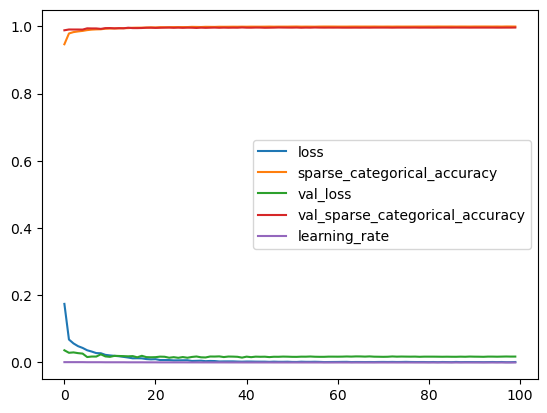

In [12]:
import pandas as pd

pd.DataFrame(
    classifier.history.history
).plot()

In [13]:
predictions = classifier.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [14]:
import numpy as np

predictions = np.argmax(predictions, axis=1)

In [15]:
predictions

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))

In [20]:
from sklearn.metrics import classification_report

print(classification_report(y_true=y_test, y_pred=predictions, digits=4))

              precision    recall  f1-score   support

           0     0.9959    0.9990    0.9975       980
           1     0.9947    0.9991    0.9969      1135
           2     0.9981    0.9971    0.9976      1032
           3     0.9970    0.9980    0.9975      1010
           4     0.9939    0.9959    0.9949       982
           5     0.9966    0.9955    0.9961       892
           6     0.9989    0.9916    0.9953       958
           7     0.9971    0.9961    0.9966      1028
           8     0.9990    0.9969    0.9979       974
           9     0.9950    0.9960    0.9955      1009

    accuracy                         0.9966     10000
   macro avg     0.9966    0.9965    0.9966     10000
weighted avg     0.9966    0.9966    0.9966     10000



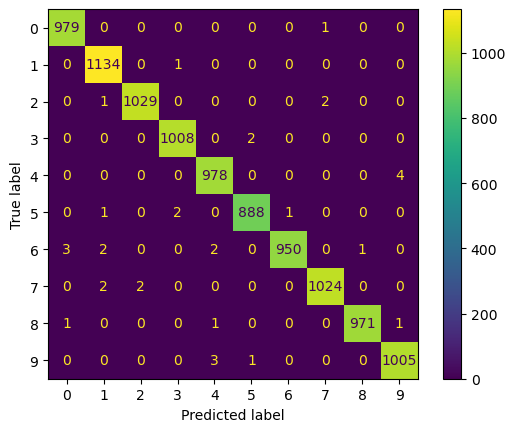

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_pred=predictions, y_true=y_test)

In [17]:
index_array = []

for i in range(len(y_test)):
    if y_test[i] == 7:
        index_array.append(i)



index_array

[0,
 17,
 26,
 34,
 36,
 41,
 60,
 64,
 70,
 75,
 79,
 80,
 83,
 86,
 97,
 111,
 114,
 122,
 124,
 133,
 141,
 144,
 171,
 175,
 220,
 223,
 229,
 234,
 243,
 254,
 255,
 262,
 263,
 282,
 301,
 307,
 328,
 337,
 358,
 370,
 383,
 410,
 411,
 413,
 415,
 438,
 468,
 482,
 494,
 510,
 522,
 550,
 551,
 554,
 557,
 579,
 585,
 605,
 617,
 626,
 636,
 649,
 651,
 658,
 666,
 667,
 676,
 679,
 684,
 689,
 702,
 703,
 705,
 726,
 730,
 746,
 756,
 771,
 810,
 822,
 825,
 832,
 841,
 842,
 846,
 852,
 853,
 859,
 880,
 898,
 909,
 911,
 917,
 930,
 941,
 946,
 950,
 960,
 987,
 1006,
 1012,
 1021,
 1039,
 1055,
 1071,
 1091,
 1096,
 1100,
 1104,
 1110,
 1117,
 1119,
 1122,
 1126,
 1133,
 1141,
 1143,
 1156,
 1164,
 1171,
 1173,
 1175,
 1186,
 1194,
 1206,
 1216,
 1226,
 1241,
 1244,
 1260,
 1276,
 1283,
 1321,
 1326,
 1328,
 1346,
 1347,
 1355,
 1359,
 1361,
 1363,
 1366,
 1369,
 1386,
 1401,
 1477,
 1494,
 1496,
 1497,
 1498,
 1500,
 1505,
 1507,
 1520,
 1522,
 1540,
 1543,
 1544,
 1563,
 1

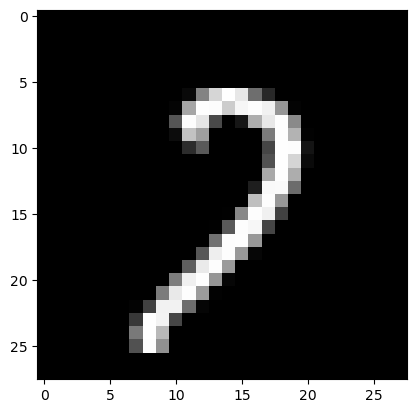

In [18]:
import random

i = random.choice(index_array)

image = x_test[i]

plt.imshow(image, cmap='gray')

In [19]:
classifier.save('best_model.keras')